## Статистическая мощность

### Ошибка False Negative

В статистике принято положительным результатом считать отвержение нулевой гипотезы, потому что обычно подтверждение альтернативы означает наличие бизнес-результата. Поэтому считается хорошим критерий, который чаще позволяет выявить бизнес-результат. И считают тогда не вероятность ошибки False Negative, а *мощность*, которая равна вероятности отвергнуть нулевую гипотезу при верности $\mathsf{H}_1$, то есть True Positive Rate.

## Мощность для задачи с доставкой

Применим новые знания о мощности для нашей задачи с доставкой. Из бизнес-соображений мы уже выбрали $\alpha = 0.05$, а значит знаем, что мы неправильно отвергаем гипотезу $\mathsf{H}_0:\ \mu = 0.5$ с вероятностью не более, чем $5\%$. То есть этим ограничена вероятность ошибки False Positive.

А с какой вероятностью мы будем *правильно* отвергать гипотезу? И какая у нас будет вероятность ошибки False Negative? На этот вопрос как раз ответит формула мощности.

Вспомним критерий, по которому мы принимаем решение:

$$ Q(\xi) = \sum\limits_{i=1}^n \xi_i - \text{количество успешных доставок} $$

$$ S = \{Q \geqslant 20\} $$

То есть если получаем хотя бы $20$ успешных доставок, то отвергаем $\mathsf{H}_0$.

Заметим, что, как и в прошлом пункте, мощность зависит от того, какое значение $\mu$ в нашей генеральной совокупности. Зафиксируем сначала параметр $\mu = 0.6$ и посчитаем мощность для него. Если истинный параметр такой, то статистика $Q$ имеет распределение $Binom(30, 0.6)$.

In [65]:
%matplotlib inline
from scipy.stats import binom
import numpy
from matplotlib import pyplot

In [66]:
binom_h0 = binom(n=30, p=0.5)
binom_alternative = binom(n=30, p=0.6)
x_grid = numpy.arange(1, 31)
crit_reg = x_grid >= 20
probs_h0 = binom_h0.pmf(x_grid)
probs_alternative = binom_alternative.pmf(x_grid)

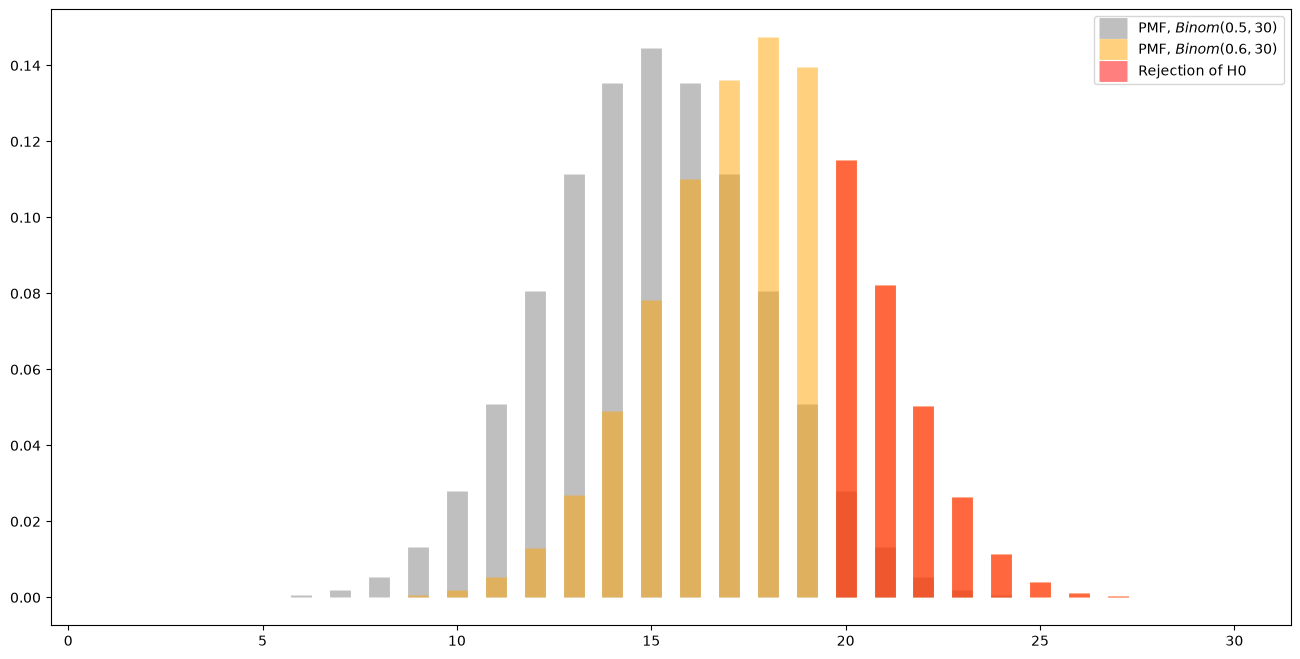

In [67]:
pyplot.figure(figsize=(16, 8))
pyplot.vlines(
    x_grid,
    0,
    probs_h0,
    linewidth=15.0,
    color="grey",
    label="PMF, $Binom(0.5, 30)$",
    alpha=0.5,
)
pyplot.vlines(
    x_grid,
    0,
    probs_alternative,
    linewidth=15.0,
    color="orange",
    label="PMF, $Binom(0.6, 30)$",
    alpha=0.5,
)
pyplot.vlines(
    x_grid[crit_reg],
    0,
    probs_alternative[crit_reg],
    linewidth=15.0,
    color="red",
    label="Rejection of H0",
    alpha=0.5,
)

pyplot.legend()
pyplot.show()

Число 20 искалось, просто повторение кода прошлого

In [68]:
def make_binom_criterion(n, mu=0.5, alpha=0.05):
    """Строит критерий для задачи с доставкой

    Параметры:
        n: количество доставок в эксперименте
        mu: вероятность успеха в нулевой гипотезе
        alpha: уровень значимости критерия

    Возвращает:
        C для критерия S = {Q >= C}
    """
    binom_for_delivery = binom(n, mu)
    return binom_for_delivery.ppf(1 - alpha) + 1

In [69]:
make_binom_criterion(n=30, mu=0.5, alpha=0.05)

np.float64(20.0)

Как и раньше, нас интересует вероятность получить $20$ или более успехов. Но если раньше мы смотрели на неё для распределения с $\mu=0.5$ и хотели, чтобы она была меньше $5\%$, то теперь мы смотрим при $\mu = 0.6$ и стремимся сделать эту величину как можно больше. По сравнению с вычислением FPR формула не поменяется, изменяется только $\mu$

In [70]:
critical_value = 20
fpr = 1 - binom(n=30, p=0.5).cdf(critical_value - 1)
power = 1 - binom(n=30, p=0.6).cdf(critical_value - 1)

print(f"False Positive Rate is {fpr:.1%}")
print(f"Power is {power:.1%}")

False Positive Rate is 4.9%
Power is 29.1%


Видно, что мощность около $30\%$. Это довольно маленькое значение, ведь если наш продукт прибылен, то мы увидим это с помощью нашего теста только с вероятностью в $30$ процентов. Мы легко можем пропустить эффект.

Что же можно сделать, чтобы сделать мощность выше? Чтобы разобраться, реализуем функцию мощности в общем виде.

In [71]:
def get_stat_power(N, mu_h0, mu_alternative, alpha):
    """Вычисляет статистическую мощность критерия для биномиального распределения

    Параметры:
        N - количество бернуллиевских экспериментов (размер выборки)
        mu_h0 - вероятность успеха в нулевой гипотезе
        mu_alternative - предполагаемая вероятность успеха в эксперименте
        alpha - уровень значимости критерия
    """
    binom_h0 = binom(N, mu_h0)
    binom_alternative = binom(N, mu_alternative)
    critical_value = binom_h0.ppf(1 - alpha) + 1
    return 1 - binom_alternative.cdf(critical_value - 1)

In [72]:
get_stat_power(30, 0.5, 0.6, alpha=0.05)

np.float64(0.2914718612234968)

In [73]:
get_stat_power(300, 0.5, 0.6, alpha=0.05)

np.float64(0.9655326717180744)

Принято считать, что приемлемой для работы мощностью считается $80\%$. Посмотрим, как изменяется мощность при росте размера выборки, и сколько нужно провести экспериментов, чтобы детектировать эффект при $\mu = 0.6$ в $80\%$ случаев.

In [74]:
n_grid = numpy.arange(10, 600, 10)
power = get_stat_power(n_grid, 0.5, 0.6, 0.05)

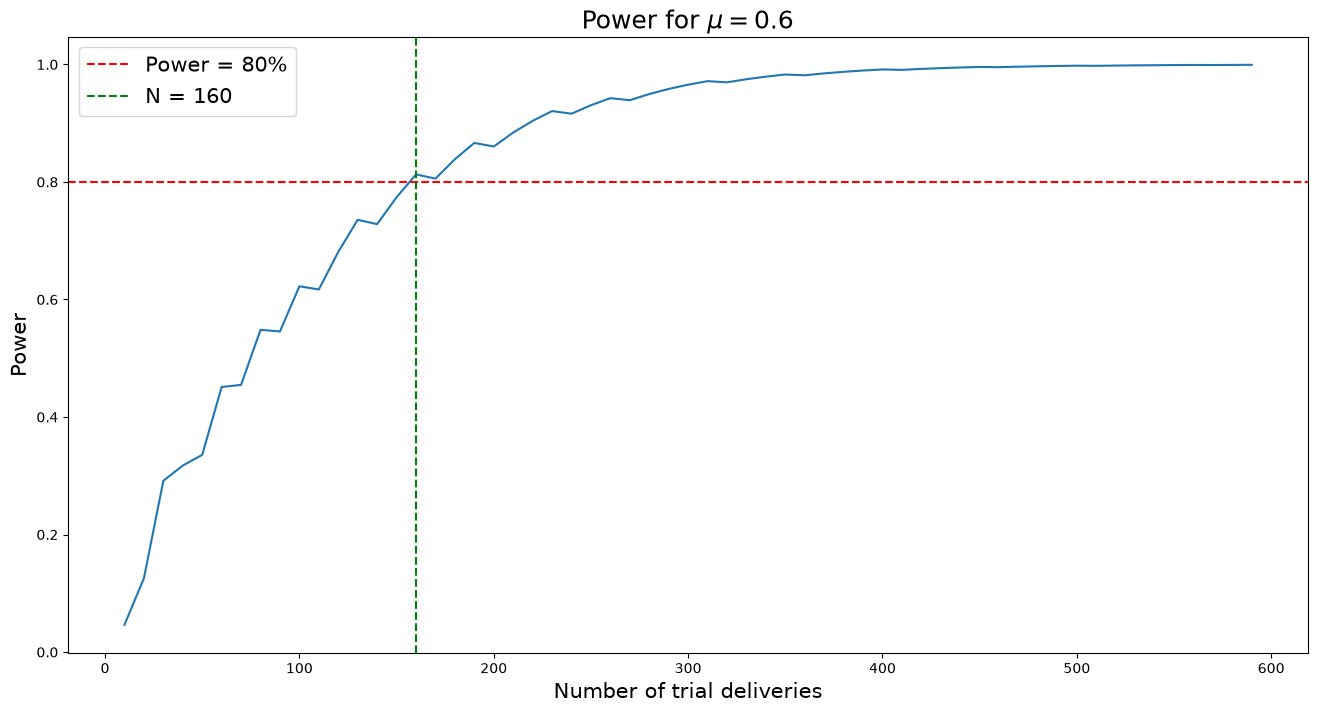

In [75]:
from cProfile import label

pyplot.figure(figsize=(16, 8))
pyplot.title(r"Power for $\mu = 0.6$", fontsize=18)
pyplot.xlabel("Number of trial deliveries", fontsize=15)
pyplot.ylabel("Power", fontsize=15)
pyplot.plot(n_grid, power)
pyplot.axhline(0.8, ls="--", color="red", label="Power = 80%")
min_n = n_grid[power >= 0.8].min()
pyplot.axvline(float(min_n), ls="--", color="green", label=f"N = {min_n}")
pyplot.legend(fontsize=15)
pyplot.show()

Видим, что для мощности в $80\%$ достаточно набрать 160 доставок.

А что, если мы хотим детектировать ещё меньший эффект? Например, если хотим отвергать гипотезу при $\mu = 0.51$. Часто улучшение вероятности успеха на $1\%$ может быть значимым для продукта, поэтому этот вопрос не лишен смысла.

In [76]:
n_grid = numpy.arange(10, 30000, 10)
power = get_stat_power(N=n_grid, mu_h0=0.5, mu_alternative=0.51, alpha=0.05)

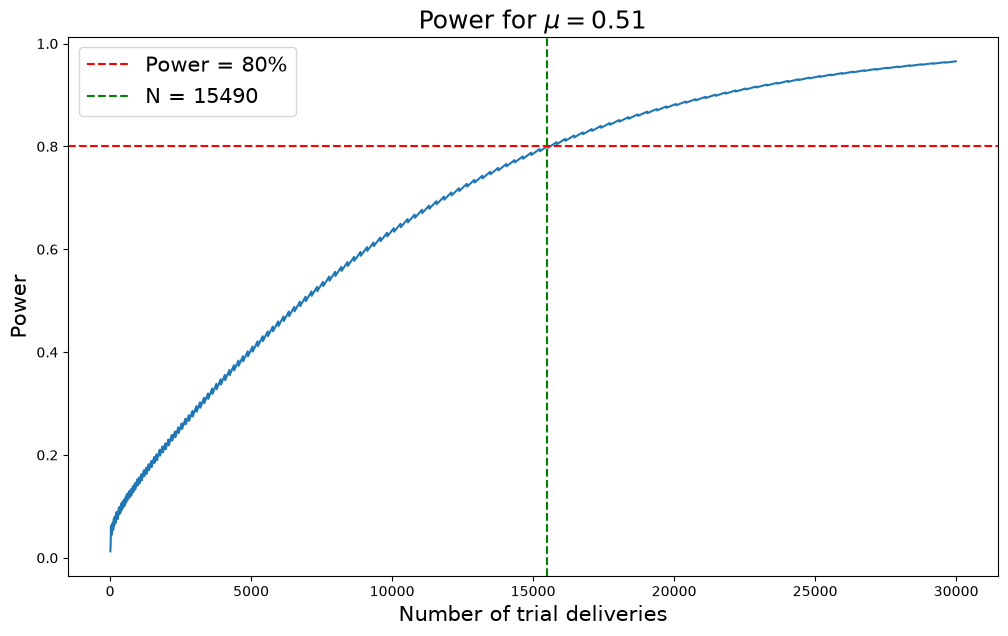

In [77]:
pyplot.figure(figsize=(12, 7))
pyplot.title(r"Power for $\mu = 0.51$", fontsize=18)
pyplot.xlabel("Number of trial deliveries", fontsize=15)
pyplot.ylabel("Power", fontsize=15)

pyplot.plot(n_grid, power)
pyplot.axhline(0.8, ls="--", color="red", label="Power = 80%")

# считаем минимальный размер выборки для мощности в 80%
min_n = n_grid[power >= 0.8][0]
pyplot.axvline(min_n, ls="--", color="green", label=f"N = {min_n}")

pyplot.legend(fontsize=15)
pyplot.show()

In [78]:
mu_grid = numpy.linspace(0.5, 1, 500)
power = get_stat_power(N=30, mu_h0=0.5, mu_alternative=mu_grid, alpha=0.05)

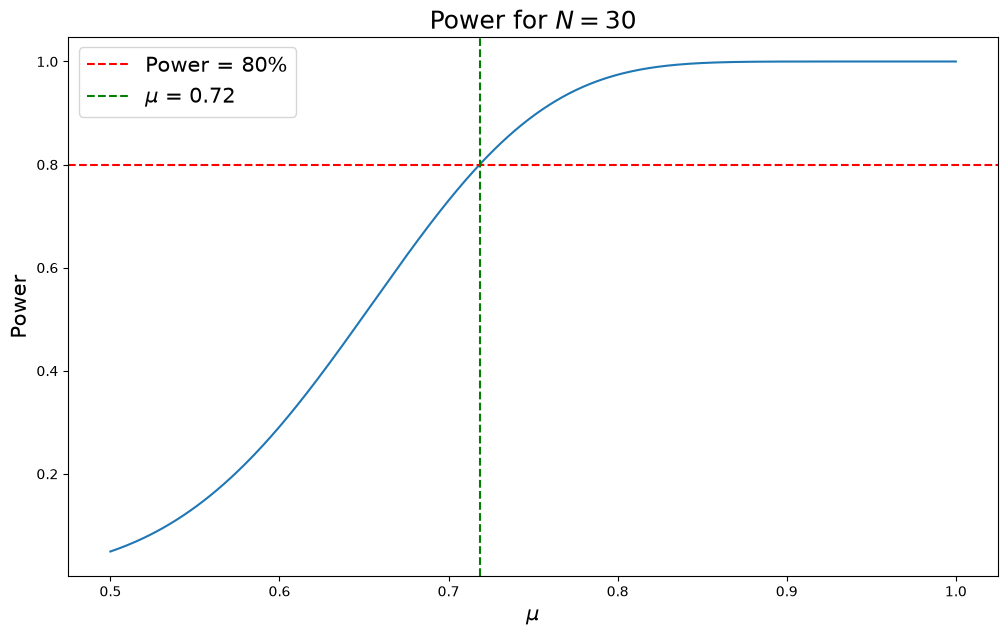

In [79]:
pyplot.figure(figsize=(12, 7))
pyplot.title("Power for $N = 30$", fontsize=18)
pyplot.xlabel(r"$\mu$", fontsize=15)
pyplot.ylabel("Power", fontsize=15)

pyplot.plot(mu_grid, power)
pyplot.axhline(y=0.8, color="red", linestyle="--", label="Power = 80%")
min_mu = mu_grid[power >= 0.8][0]
pyplot.axvline(min_mu, ls="--", color="green", label=rf"$\mu$ = {min_mu:.2f}")
pyplot.legend(fontsize=15)
pyplot.show()

В нашем эксперименте мы хорошо детектируем эффект, только если вероятность успеха в генеральной совокупности хотя бы $72\%$.

### MDE

Перед запуском экспериментов аналитики сообщают минимальную величину эффекта, которую можно задетектировать. Она так и называется, **минимальный детектируемый эффект**, сокращённо MDE (Minimal Detectable Effect). В нашем случае $MDE = +22$ п.п. 

Более формально, $MDE$ для гипотезы $\mathsf{H}_0: \mu = \mu_0$ &mdash; это минимальный эффект $\delta$, при котором критерий уровня значимости $\alpha$ для проверки этой гипотезы при истинном параметре $\mu = \mu_0 + \delta$ и размере выборки $N$ будет отвергать $\mathsf{H}_0$ с мощностью большей, чем $1 - \beta$.

Чаще всего берут $1 - \beta = 80\%$. Напишем функцию, которая будет вычислять MDE подбором.

In [80]:
def binom_test_mde_one_sided(N, mu0, alpha=0.05, min_power=0.8):
    """Вычисляет MDE одностороннего критерия для проверки гипотезы mu = mu0 в задаче с доставкой

    Параметры:
        N (int) - размер выборки
        mu0 (float) - вероятность успеха в нулевой гипотезе
        alpha (float) - уровень значимости критерия
        min_power (float) - желаемая мощность

    Возвращает:
        float - MDE"""
    delta_grid = numpy.linspace(0, 1 - mu0, 500)
    power = get_stat_power(N, mu0, mu0 + delta_grid, alpha)
    return delta_grid[power >= min_power][0]

Вызовем функцию для нашего случая

In [81]:
binom_test_mde_one_sided(30, 0.5)

np.float64(0.21843687374749496)

Обычно MDE считают не просто так, а неразрывно с ним идёт вопрос об определении размера выборки.

**Определение размера выборки**

В нашей задаче мы нашли $30$ клиентов, не вычисляя изначально, сколько их понадобится. Но что если полученный MDE слишком велик и нужно сделать его меньше, поскольку ожидаемые изменения гораздо меньше? Тогда решается обратная задача, По требуемому MDE определить объём выборки. Если мы говорим, что хотим детектировать +10 п.п., то есть 60% успешных доставок, то потребуется найти 160 пробных клиентов, это видно из предыдущих графиков. Если 30 человек нам, например, искать месяц, такой тест может затянуться почти на полгода.

## Доверительные интервалы

Если гипотеза $\mathsf{H}_0$ не отвергается, это значит, что значение $\mu = 0.5$ допустимо для нашей выборки. Полученные значения можно объяснить значением $\mu = 0.5$. Но если у нас есть механизм проверки для любого $\mu$, мы можем для всех значений узнать, какие из них допустимы и получить множество возможных значений $\mu$. Такое множество называется доверительным интервалом.

*Доверительный интервал* уровня доверия $1 - \alpha$ &mdash; множество значений параметра $\mu_0$, для которых гипотеза $\mu = \mu_0$ не отвергается критерием уровня значимости $\alpha$.


Из определения следует, что разные критерии могут порождать разные доверительные интервалы. Рассмотрим двусторонние критериеи. Для этого с шагом $0.001$ переберём значения $\mu \in [0, 1]$ и проверим гипотезы.

In [82]:
def two_sided_criterion_nonsym(n, mu, alpha):
    """Строит двусторонний критерий для несимметричной задачи с доставкой

    Параметры:
        n: количество доставок в эксперименте
        mu: вероятность успеха в нулевой гипотезе
        alpha: уровень значимости критерия

    Возвращает:
        C1, C2 для критерия S = {Q <= C1 или Q >= C2}
    """
    binom_h0 = binom(n=n, p=mu)
    с2 = binom_h0.ppf(1 - alpha / 2) + 1
    с1 = binom_h0.ppf(alpha / 2) - 1
    return с1, с2

In [83]:
success_cnt = 28
mu_grid = numpy.arange(0, 1.001, 0.001)
mu_no_rejection = []

for mu_h0 in mu_grid:
    c1, c2 = two_sided_criterion_nonsym(n=30, mu=mu_h0, alpha=0.1)
    if success_cnt > c1 and success_cnt < c2:
        mu_no_rejection.append(mu_h0)

min_interval = min(mu_no_rejection)
max_interval = max(mu_no_rejection)
# либо просто mu_no_rejection[0] и mu_no_rejection[-1]
print(f"95% confidence interval: {min_interval:.3f} -- {max_interval:.3f}")

95% confidence interval: 0.805 -- 0.988


Пример для $19$ успехов. Для каждого $\mu_0$ статистика $Q$ имеет распределение $Binom(30, \mu_0)$. Будем рисовать это распределение и смотреть, попадает ли $19$ в критическую область.

In [84]:
mus_h0 = [0.2, 0.438, 0.439, 0.8, 0.81, 0.9]
success_cnt = 19

29.0 11.0
29.0 19.0
29.0 19.0
29.0 28.0
29.0 29.0
29.0 30.0


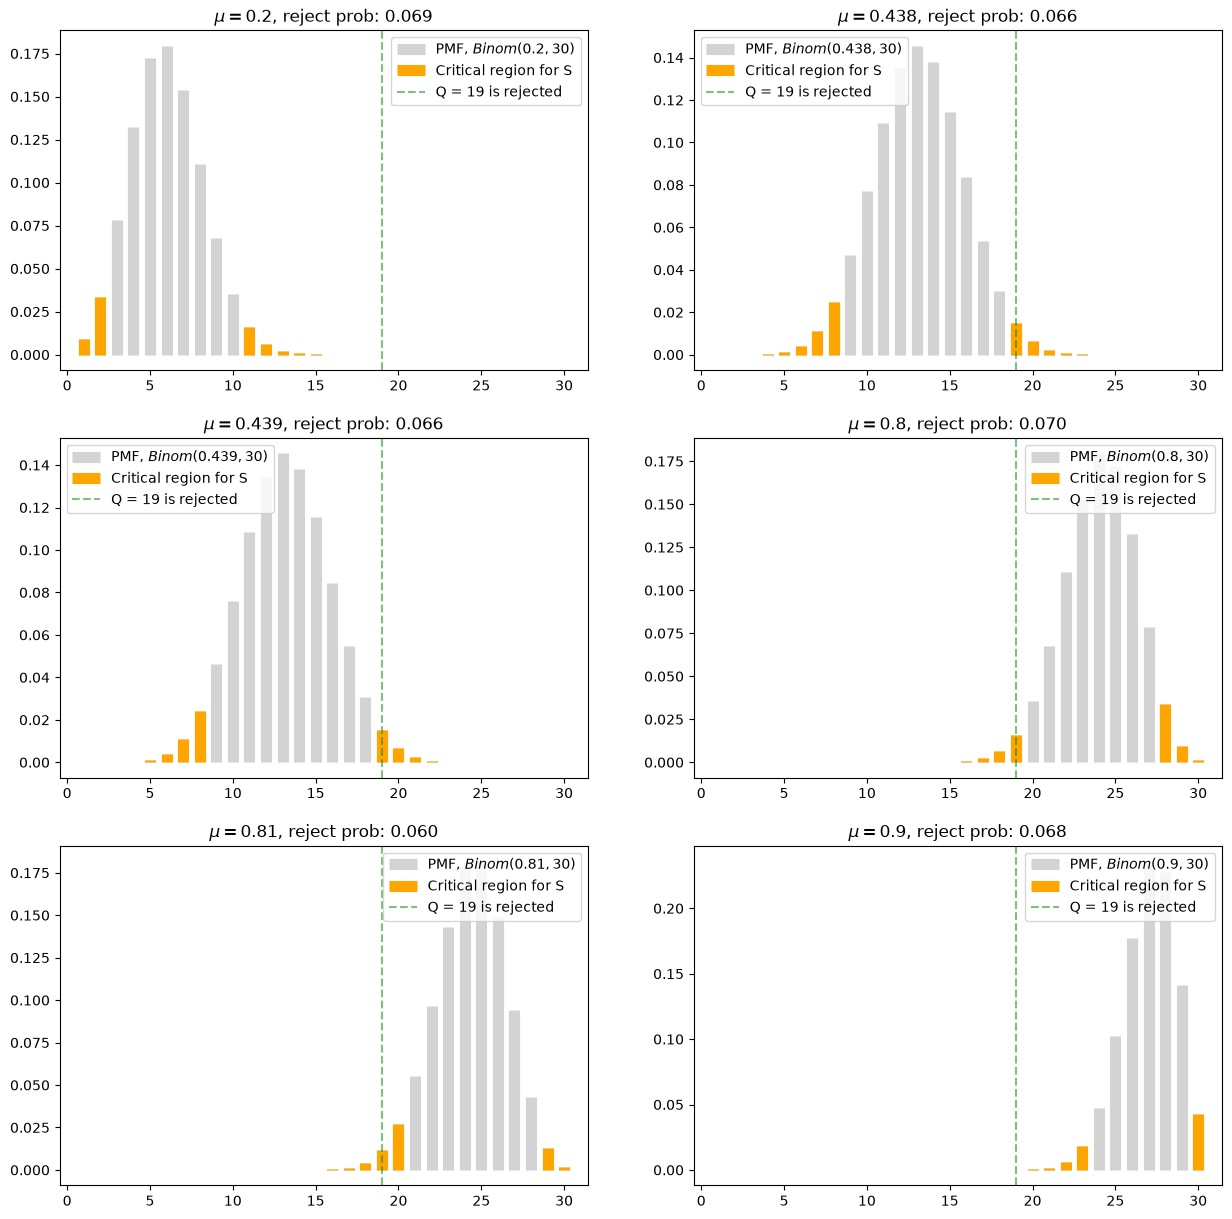

In [85]:
fig, axes = pyplot.subplots(3, 2, figsize=(15, 15))

for mu_h0, ax in zip(mus_h0, axes.flatten()):
    binom_h0 = binom(30, mu_h0)
    probs = binom_h0.pmf(x_grid)
    ax.vlines(
        x_grid,
        0,
        probs,
        linewidth=8.0,
        color="lightgray",
        label=f"PMF, $Binom({mu_h0}, 30)$",
    )
    с1, c2 = two_sided_criterion_nonsym(30, mu_h0, alpha=0.1)
    print(c1, c2)
    crit_reg = (x_grid <= с1) | (x_grid >= c2)
    ax.vlines(
        x_grid[crit_reg],
        0,
        probs[crit_reg],
        color="orange",
        linewidth=8.0,
        label="Critical region for S",
    )
    is_rejection = success_cnt <= c1 or success_cnt >= c2
    ax.axvline(
        success_cnt,
        ls="--",
        label=f"Q = {success_cnt} "
        + ("is rejected" if is_rejection else "is not rejected"),
        color="green",
        alpha=0.5,
    )

    rejection_prob = probs[crit_reg].sum()
    ax.set_title(rf"$\mu = {mu_h0}$, reject prob: {rejection_prob:.3f}", fontsize=12)
    ax.legend()

## Односторонние доверительные интервалы

До этого мы использовали двусторонний критерий, и из него получился доверительный интервал. Но на прошлой лекции мы говорили, что двусторонний критерий нужен крайне редко. Контролировать ошибку False Positive нам нужно только для отклонений в сторону, полезную для бизнеса. В случае задачи с доставкой это получение *большей* конверсии в успех.

Попробуем воспользоваться односторонним критерием для построения доверительного интервала.

In [86]:
def make_binom_criterion(n, mu=0.5, alpha=0.05):
    """Строит критерий для задачи с доставкой

    Параметры:
        n: количество доставок в эксперименте
        mu: вероятность успеха в нулевой гипотезе
        alpha: уровень значимости критерия

    Возвращает:
        C для критерия S = {Q >= C}
    """
    binom_h0 = binom(n, mu)
    q = binom_h0.ppf(1 - alpha)
    return q + 1

In [ ]:
success_cnt = 19
mu_grid = numpy.arange(0, 1.001, 0.001)
mu_no_rejection = []
for mu_h0 in mu_grid:
    crit_val = make_binom_criterion(n=30, mu=mu_h0, alpha=0.05)
    if success_cnt < crit_val:
        mu_no_rejection.append(mu_h0)
min_interval = min(mu_no_rejection)
max_interval = max(mu_no_rejection)

print(f"95% confidence interval: {min_interval} -- {max_interval}")

95% confidence interval: 0.467 -- 1.0


Предположим, мы получили не $19$ успехов, а $22$. Построим 2 вида интервалов.

In [ ]:
success_cnt = 22
mu_grid = numpy.arange(0, 1.001, 0.001)
mu_no_rejection = []
for mu_h0 in mu_grid:
    c1, c2 = two_sided_criterion_nonsym(n=30, mu=mu_h0, alpha=0.1)
    if c1 < success_cnt < c2:
        mu_no_rejection.append(mu_h0)

min_interval = min(mu_no_rejection)
max_interval = max(mu_no_rejection)

print(f"90% confidence interval: {min_interval} -- {max_interval}")

90% confidence interval: 0.5710000000000001 -- 0.859


In [ ]:
success_cnt = 22
mu_grid = numpy.arange(0, 1.001, 0.001)
mu_no_rejection = []
for mu_h0 in mu_grid:
    crit_val = make_binom_criterion(n=30, mu=mu_h0, alpha=0.05)
    if success_cnt < crit_val:
        mu_no_rejection.append(mu_h0)

min_interval = min(mu_no_rejection)
max_interval = max(mu_no_rejection)
print(f"95% confidence interval: {min_interval} -- {max_interval}")

95% confidence interval: 0.5710000000000001 -- 1.0


## Свойства доверительных интервалов

Вспомним определение доверительного интервала.

Пусть есть критерий $S = \{Q(\xi) \leqslant C\}$ уровня значимости $\alpha$ для проверки гипотезы $\mathsf{H}_0: \mu = \mu_0$, $Q$ &mdash; статистика критерия, а $q$ &mdash; её реализация на конкретной выборке $\xi = \xi_1, \dots, \xi_n$. Тогда **доверительным интервалом** называется множество таких $\mu_0$, на которых критерий $S$ не отвергает гипотезу $\mathsf{H}_0: \mu = \mu_0$.

Процедура подсчёта интервала в прошлой части &mdash; это долгий перебор значений с некоторым шагом. Но это всё ещё остаётся некоторой функцией от выборки, то есть *статистикой* и случайной величиной, причём её распределение зависит от статистики $Q$, а значит и от изначальной выборки, и от параметра $\mu$ в генеральной совокупности.

Обозначим границы интервала за $\mathcal{L}(Q), \mathcal{R}(Q)$ &mdash; статистики

**Свойство доверительного интервала**

Каким бы ни было истинное значение $\mu = \mu_0$, вероятность того, что оно находится между $\mathcal{L}(Q)$ и $\mathcal{R}(Q)$, не ниже, чем $1 - \alpha$. Значение $1 - \alpha$ называется **уровнем доверия** доверительного интервала.

$$ P(\mathcal{L}(Q) < \mu_0 < \mathcal{R}(Q)) \geqslant 1 - \alpha $$

Важно, что случайность здесь скрыта именно в $\mathcal{L}$ и $\mathcal{R}$, а не в $\mu_0$. Параметр $\mu_0$ неизвестен, но мы предполагаем его константным и не случайным.

Проверим справедливость этого свойства. Для этого зафиксируем $\mu_0$ и проведём множество экспериментов:

* Генерируем выборку из распределения с параметром $\mu_0$
* Вычисляем статистику $q$
* Считаем доверительный интервал для $\alpha = 0.05$

Проверяем, что доля случаев, когда параметр $\mu_0$ оказался внутри границ интервала, хотя бы $95\%$

In [ ]:
def my_binomial_confint(n, alpha, q):
    """Вычисляет доверительный интервал для выборки из распределения Бернулли

    n (int) - количество элементов в выборке
    alpha (float) - уровень значимости критерия
    q (float) - реализация статистики критерия
    """
    mu_grid = numpy.arange(0, 1.001, 0.001)
    mu_no_rejection = []
    for mu in mu_grid:
        c1, c2 = two_sided_criterion_nonsym(n, mu, alpha)
        if c1 < q < c2:
            mu_no_rejection.append(mu)
    return min(mu_no_rejection), max(mu_no_rejection)

In [91]:
numpy.random.seed(202312)

In [ ]:
N_EXPERIMENTS = 1000
SAMPLE_SIZE = 30
latent_mu = 0.5  # "истинное" значение параметра
binom_true = binom(n=SAMPLE_SIZE, p=latent_mu)  # "истинное" распрееление

confint_fail_cases = 0

for i in range(N_EXPERIMENTS):
    q = binom_true.rvs()  # генерируем сразу сумму элементов
    L, R = my_binomial_confint(n=SAMPLE_SIZE, alpha=0.05, q=q)
    if L < latent_mu < R:
        pass  # всё хорошо
    else:
        confint_fail_cases += 1

print(1 - confint_fail_cases / N_EXPERIMENTS)

0.961


**Доказательство свойства**

При формулировке свойства мы предполагаем, что есть некоторая $\mu_0$ &mdash; вероятность успеха в генеральной совокупности. Когда мы проводим искусственный эксперимент, мы фиксируем её и можем считать истинной $\mu$.

Каждый раз мы генерируем $Q \sim Binom(\mu_0, 30)$ и проверяем, попала ли $\mu_0$ в доверительный интервал. Нарисуем распределение статистики $Q$, которое уже нам знакомо. Нарисуем и область вероятности $\leqslant \alpha$, как мы делали это раньше.

In [93]:
mu0 = 0.5
x_grid = numpy.arange(1, 31)
binom_mu0 = binom(30, mu0)
probs = binom_mu0.pmf(x_grid)

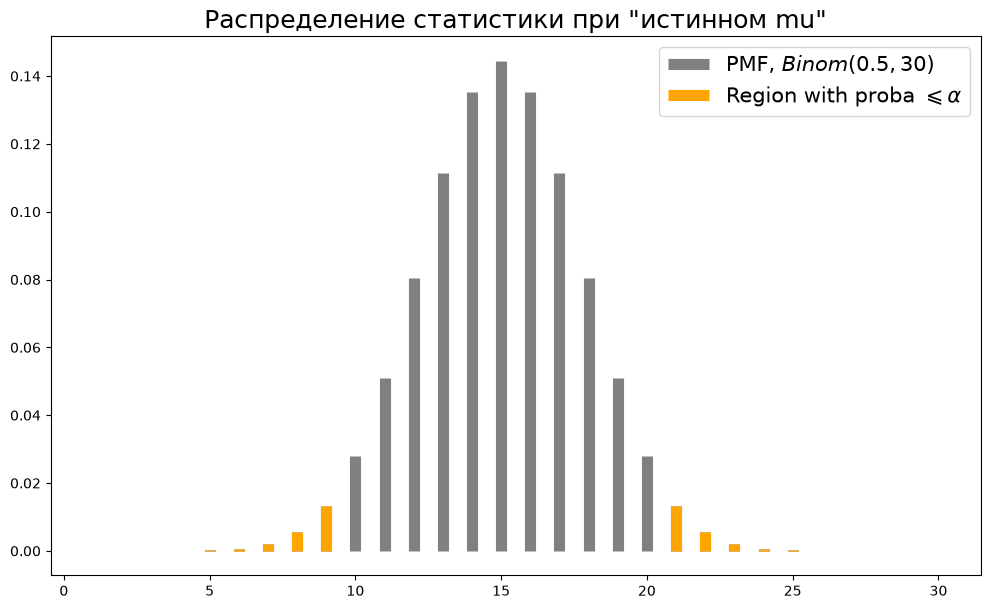

In [ ]:
pyplot.figure(figsize=(12, 7))
pyplot.title('Распределение статистики при "истинном mu"', fontsize=18)

pyplot.vlines(
    x_grid, 0, probs, linewidth=8.0, color="grey", label=f"PMF, $Binom({mu0}, 30)$"
)
c1, c2 = two_sided_criterion_nonsym(30, mu0, 0.05)
crit_reg = (x_grid <= c1) | (x_grid >= c2)
pyplot.vlines(
    x_grid[crit_reg],
    0,
    probs[crit_reg],
    linewidth=8.0,
    color="orange",
    label="Region with proba $\\leqslant \\alpha$",
)

pyplot.legend(fontsize=15)
pyplot.show()

Пусть реализовалось значение статистики $q$. По такой выборке можно построить доверительный интервал на $\mu$. Он будет как-то расположен, но сейчас нас интересует, попадёт ли в него $\mu_0$. По определению попадание в интервал произойдёт $\Leftrightarrow$ не отвергается гипотеза $\mathsf{H}_0:\ \mu = \mu_0$. Но тогда при справедливости $\mathsf{H}_0$ статистика имеет то распределение, что и на рисунке. И гипотеза отвергается только при попадании в рыжую критическую область, а это случается с вероятностью $\leqslant \alpha$.

Значит с вероятностью хотя бы $1 - \alpha$ $\mu_0$ будет находиться в доверительном интервале.

Часто так и вводят определение доверительного интервала. Для выборки $\xi_1, \dots, \xi_n$ &mdash; это такая пара статистик $\mathcal{L}(\xi)$ и $\mathcal{R}(\xi)$, что каким бы ни было $\mu_0$,

$$P(L(\xi) < \mu_0 < R(\xi)) \geqslant 1 - \alpha$$

Снова обращаем внимание, что случайность здесь скрыта не в параметре $\mu_0$, а в статистиках от выборки.

#### **Приближённое построение интервала**

Рассмотренный сейчас алгоритм построение доверительного интервала работает слишком долго. В Python есть функции, которые позволяют быстрее рассчитать интервал. Например, можно воспользоваться методом Уилсона и функцией `proportion_confint`

In [95]:
from statsmodels.stats.proportion import proportion_confint

In [96]:
numpy.random.seed(202312)

In [99]:
N_EXPERIMENTS = 1000
SAMPLE_SIZE = 30
latent_mu = 0.5  # "истинное" значение параметра
binom_true = binom(n=SAMPLE_SIZE, p=latent_mu)  # "истинное" распрееление

confint_fail_cases = 0

for i in range(N_EXPERIMENTS):
    q = binom_true.rvs()  # генерируем сразу сумму элементов
    L, R = proportion_confint(count=q, nobs=SAMPLE_SIZE, alpha=0.05, method='wilson')
    if L < latent_mu < R:
        pass # всё хорошо
    else:
        confint_fail_cases += 1

print(1 - confint_fail_cases / N_EXPERIMENTS)

0.952


In [102]:
n_grid = numpy.arange(1, 1000, 25)
interval_success_rate = []

for n in n_grid:
    confint_fail_cases = 0
    for i in range(N_EXPERIMENTS):
        binom_true = binom(n=n, p=latent_mu)
        q = binom_true.rvs()
        L, R = proportion_confint(
            count=q,  # количество успехов
            nobs=n,  # размер выборки
            alpha=0.05,
            method='wilson'
        )
        if L < latent_mu < R:
            pass # всё хорошо
        else:
            confint_fail_cases += 1
    interval_success_rate.append(1 - confint_fail_cases / N_EXPERIMENTS)

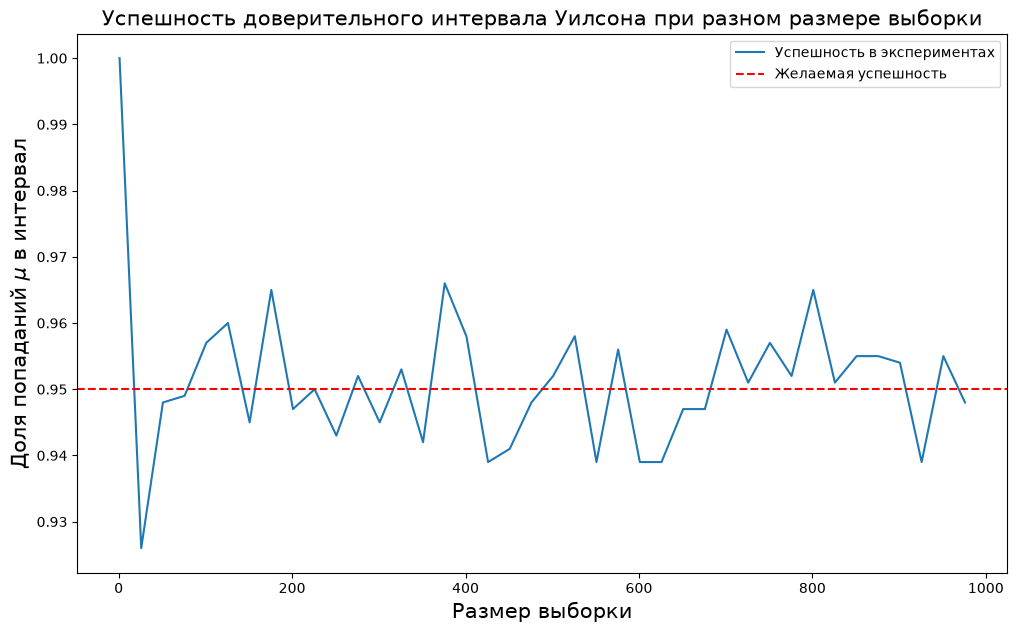

In [108]:
pyplot.figure(figsize=(12, 7))
pyplot.title('Успешность доверительного интервала Уилсона при разном размере выборки', fontsize=15)
pyplot.xlabel('Размер выборки', fontsize=15)
pyplot.ylabel(r'Доля попаданий $\mu$ в интервал', fontsize=15)

pyplot.plot(n_grid, interval_success_rate, label='Успешность в экспериментах')
pyplot.axhline(0.95, ls='--', label='Желаемая успешность', color='red')
pyplot.legend()
pyplot.show()

Видно, что на любом размере выборки при использовании интервала Уилсона можно получить меньше $95\%$ попаданий, но чем больше размер выборки, тем меньше график отклоняется от $95\%$.